# Tarea 2: Health Landscape — ENO + GRD
**Curso:** IELE756 — Preparación y Análisis de Datos  
**Comunas asignadas:** Quilicura (13122), La Reina (13109), Tiltil (13125)


In [1]:
import os, io, zipfile, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import geopandas as gpd
warnings.filterwarnings('ignore')

os.makedirs('output', exist_ok=True)

# ── Constantes ────────────────────────────────────────────────────────────────
MY_COMUNAS     = [13109, 13122, 13125]
MY_COMUNAS_STR = [str(c) for c in MY_COMUNAS]

COMUNA_NAMES = {
    13109: 'La Reina',
    13122: 'Quilicura',
    13125: 'Tiltil',
}
# Nombres tal como aparecen en GRD (columna COMUNA)
COMUNA_GRD = {
    13109: 'LA REINA',
    13122: 'QUILICURA',
    13125: 'TILTIL',
}
GRD_TO_CODE = {v: k for k, v in COMUNA_GRD.items()}

# ── Rutas ─────────────────────────────────────────────────────────────────────
ENO_PATH   = 'iele26_data/eno/20241218_base_eno_final.csv'
CIE10_PATH = 'iele26_data/grd/CIE-10.xlsx'
SHP_PATH   = 'Comunas/comunas.shp'
T1_CSV     = 'tarea1_comuna_summary (1) (2).csv'

# Zips GRD: (ruta, nombre del txt dentro del zip, encoding)
GRD_ZIPS = {
    2022: ('iele26_data/grd/GRD_PUBLICO_2022.zip', 'GRD_PUBLICO_EXTERNO_2022.txt', 'utf-16'),
    2023: ('iele26_data/grd/GRD_PUBLICO_2023.zip', 'GRD_PUBLICO_2023.txt',         'utf-16'),
    2024: ('iele26_data/grd/GRD_PUBLICO_2024.zip', 'GRD_PUBLICO_2024.txt',         'latin-1'),
}

# ── Cargar datos de población de Tarea 1 ──────────────────────────────────────
pop_df = pd.read_csv(T1_CSV)
pop_df = pop_df[pop_df['codigo_comuna'].isin(MY_COMUNAS)].set_index('codigo_comuna')
print('Datos de población (Tarea 1):')
display(pop_df[['nombre_comuna', 'pop_total', 'pct_foreign']])

Datos de población (Tarea 1):


,nombre_comuna,pop_total,pct_foreign
codigo_comuna,,,
13109,La Reina,103157,19.38
13122,Quilicura,236478,8.57
13125,Tiltil,205624,13.36


---
# Parte A: ENO — Enfermedades de Notificación Obligatoria (5 pts)


## A.0 Carga y Limpieza de Datos (1 pt)
### A.0.1 Cargar el dataset ENO


In [2]:
eno_cols = ['ENO', 'anho_notificacion', 'region', 'codigo_comuna_residencia',
            'nacionalidad', 'sexo', 'grupo_edad', 'nombre_instruccion',
            'cie_10_diagnostico', 'diagnostico', 'pais_contagio']

eno = pd.read_csv(ENO_PATH, sep=';', encoding='utf-8-sig', usecols=eno_cols)

print(f'Shape: {eno.shape}')
eno.info()

Shape: (333300, 11)
<class 'pandas.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   region                    333300 non-null  str  
 1   nacionalidad              333300 non-null  str  
 2   cie_10_diagnostico        333300 non-null  str  
 3   diagnostico               333300 non-null  str  
 4   anho_notificacion         333300 non-null  int64
 5   ENO                       333300 non-null  str  
 6   nombre_instruccion        333300 non-null  str  
 7   pais_contagio             333300 non-null  str  
 8   sexo                      333300 non-null  str  
 9   grupo_edad                333300 non-null  str  
 10  codigo_comuna_residencia  333300 non-null  str  
dtypes: int64(1), str(10)
memory usage: 28.0 MB


### A.0.2 Filtrar a las comunas asignadas

La columna `codigo_comuna_residencia` contiene códigos numéricos como strings (ej. `"13109"`) o el valor `"*****"` para registros anonimizados. Los registros anonimizados representan una limitación importante: **no es posible recuperarlos**, por lo que los conteos a nivel de comuna serán **subestimaciones** del verdadero volumen de notificaciones.


In [3]:
# Registros anonimizados en el dataset completo
n_anon = (eno['codigo_comuna_residencia'] == '*****').sum()
pct_anon = n_anon / len(eno) * 100
print(f'Registros anonimizados en ENO completo: {n_anon:,} ({pct_anon:.1f}% del total)')
print('⚠️  Caveat: los conteos comunales son subestimaciones del total real.')

# Filtrar a mis comunas
eno_com = eno[eno['codigo_comuna_residencia'].isin(MY_COMUNAS_STR)].copy()
print(f'\nFilas en mis comunas: {len(eno_com):,}')

Registros anonimizados en ENO completo: 148,217 (44.5% del total)
⚠️  Caveat: los conteos comunales son subestimaciones del total real.

Filas en mis comunas: 3,793


### A.0.3 Limpieza de la variable nacionalidad

La columna `nacionalidad` tiene tres valores: `"Chile"`, `"Extranjero"` y `"Desconocido"`. Para análisis de tasas y proporciones por nacionalidad, se excluirán los registros `"Desconocido"`, pero siempre se reportará cuántos se están descartando.


In [4]:
print('Distribución de nacionalidad en comunas filtradas:')
nat_dist = eno_com['nacionalidad'].value_counts()
nat_pct  = eno_com['nacionalidad'].value_counts(normalize=True).mul(100).round(1)
display(pd.DataFrame({'Conteo': nat_dist, 'Porcentaje (%)': nat_pct}))

n_desc = (eno_com['nacionalidad'] == 'Desconocido').sum()
print(f'\nRegistros "Desconocido" que se excluirán en análisis por nacionalidad: {n_desc:,} '
      f'({n_desc/len(eno_com)*100:.1f}% de las filas filtradas)')

# Dataset sin "Desconocido" para análisis por nacionalidad
eno_nat = eno_com[eno_com['nacionalidad'] != 'Desconocido'].copy()

Distribución de nacionalidad en comunas filtradas:


,Conteo,Porcentaje (%)
nacionalidad,,
Chile,1803,47.5
Desconocido,1447,38.1
Extranjero,543,14.3



Registros "Desconocido" que se excluirán en análisis por nacionalidad: 1,447 (38.1% de las filas filtradas)


### A.0.4 Rango temporal


In [5]:
print(f'Rango de años: {eno_com["anho_notificacion"].min()} – {eno_com["anho_notificacion"].max()}')

yearly = eno_com.groupby('anho_notificacion').size().reset_index(name='n_notif')
yearly.columns = ['Año', 'Notificaciones']
display(yearly)

Rango de años: 2007 – 2024


,Año,Notificaciones
0,2007,156
1,2008,135
2,2009,138
3,2010,113
4,2011,233
5,2012,167
6,2013,156
7,2014,165
8,2015,187
9,2016,148


---
## A.1 Tendencias de Notificación en el Tiempo (1 pt)

### A.1.1 Tendencia general


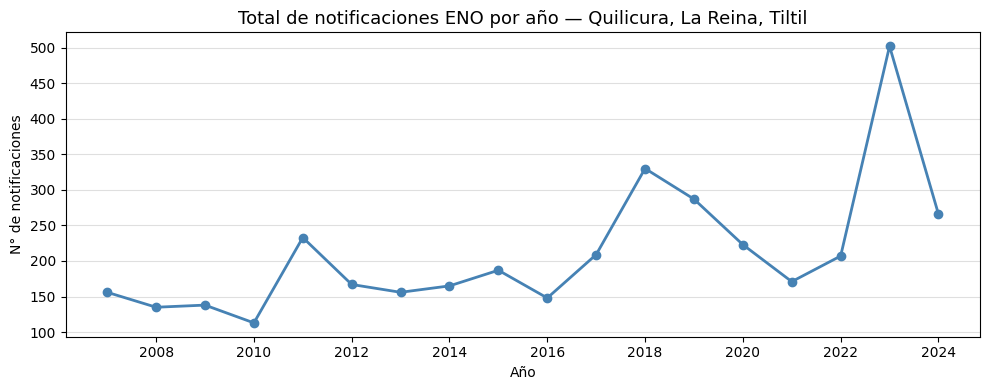

Nota: se observan caídas durante el período COVID-19 (2020–2021), probablemente por reducción de la vigilancia epidemiológica y menor consulta médica presencial.


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

yearly_total = eno_com.groupby('anho_notificacion').size()
ax.plot(yearly_total.index, yearly_total.values, marker='o', linewidth=2, color='steelblue', label='Total')

ax.set_title('Total de notificaciones ENO por año — Quilicura, La Reina, Tiltil', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('N° de notificaciones')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print('Nota: se observan caídas durante el período COVID-19 (2020–2021), '
      'probablemente por reducción de la vigilancia epidemiológica y menor '
      'consulta médica presencial.')

### A.1.2 Tendencia por nacionalidad

Se excluyen registros `"Desconocido"`. Se analiza si la proporción de notificaciones de extranjeros ha cambiado en el tiempo.


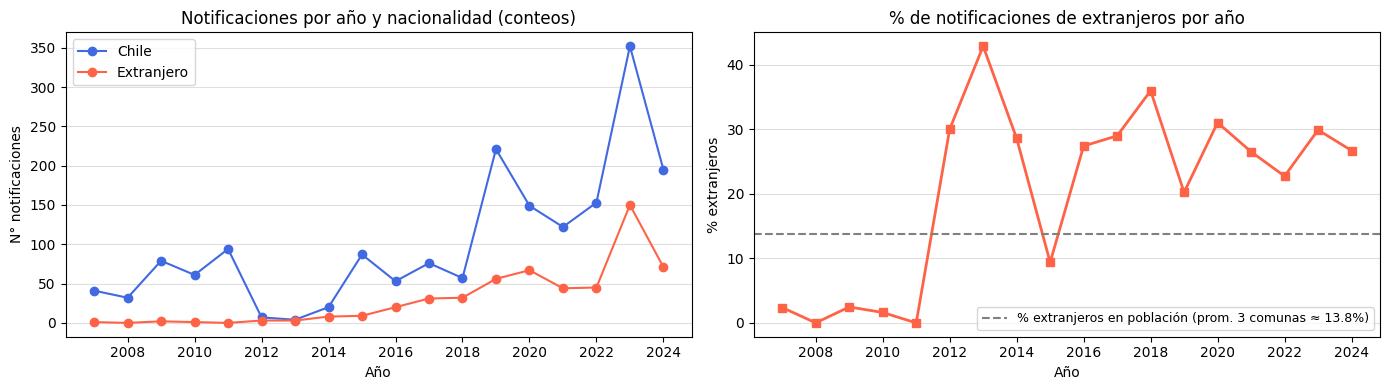

Comentario: si la línea de % extranjeros supera la línea punteada (% en población), los extranjeros están sobrerepresentados en las notificaciones.


In [7]:
trend_nat = (eno_nat
             .groupby(['anho_notificacion', 'nacionalidad'])
             .size()
             .unstack(fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Conteos absolutos
for col, color in zip(trend_nat.columns, ['royalblue', 'tomato']):
    axes[0].plot(trend_nat.index, trend_nat[col], marker='o', label=col, color=color)
axes[0].set_title('Notificaciones por año y nacionalidad (conteos)')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('N° notificaciones')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Proporción de extranjeros
prop_ext = trend_nat['Extranjero'] / trend_nat.sum(axis=1) * 100
axes[1].plot(prop_ext.index, prop_ext.values, marker='s', color='tomato', linewidth=2)
axes[1].set_title('% de notificaciones de extranjeros por año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('% extranjeros')
axes[1].axhline(pop_df['pct_foreign'].mean(), linestyle='--', color='gray',
                label=f'% extranjeros en población (prom. 3 comunas ≈ {pop_df["pct_foreign"].mean():.1f}%)')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.4)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

print('Comentario: si la línea de % extranjeros supera la línea punteada (% en población), '
      'los extranjeros están sobrerepresentados en las notificaciones.')

---
## A.2 Perfiles de Enfermedades (1.5 pts)

### A.2.1 Top 10 enfermedades notificadas (todas las comunas, todos los años)


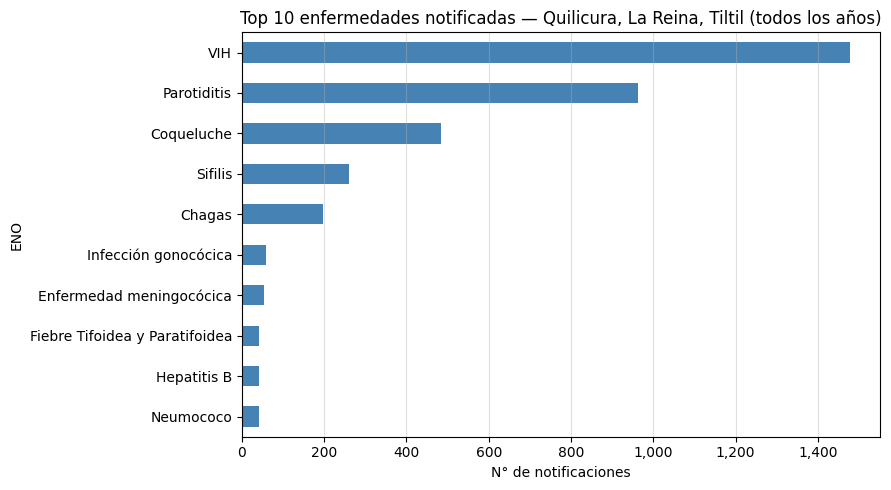

ENO
VIH                               1477
Parotiditis                        962
Coqueluche                         484
Sifilis                            260
Chagas                             198
Infección gonocócica                60
Enfermedad meningocócica            54
Fiebre Tifoidea y Paratifoidea      42
Hepatitis B                         42
Neumococo                           42


In [8]:
top10 = eno_com['ENO'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5))
top10[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 enfermedades notificadas — Quilicura, La Reina, Tiltil (todos los años)')
ax.set_xlabel('N° de notificaciones')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

print(top10.to_string())

### A.2.2 Perfil por nacionalidad — Top 5 enfermedades

Se excluyen registros `"Desconocido"`. Se analiza si alguna enfermedad tiene sobrerepresentación de extranjeros respecto a su participación en la población.


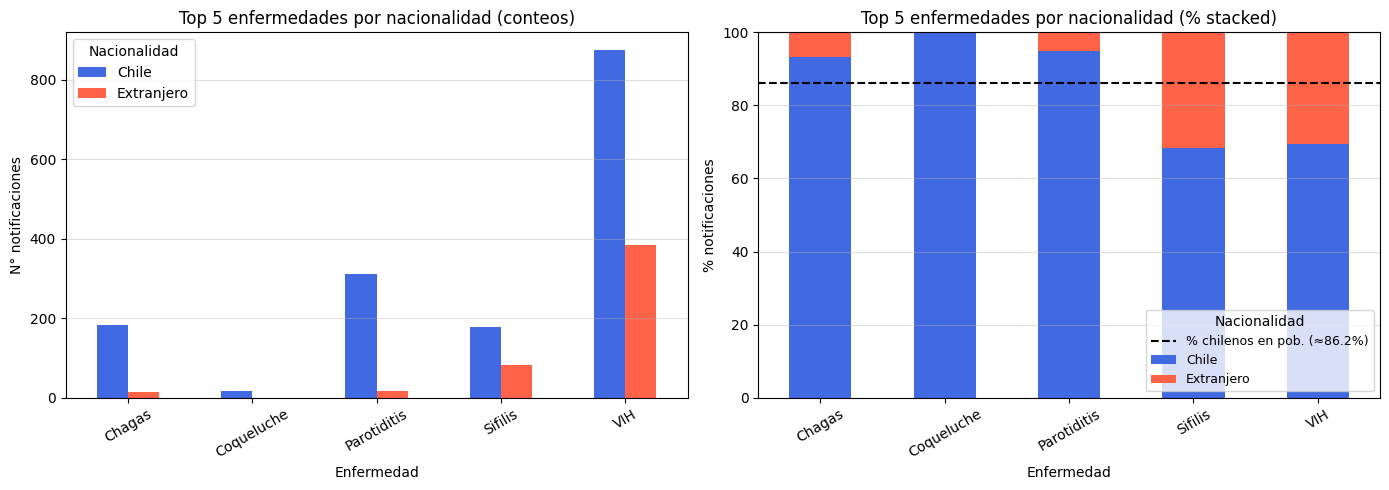

Pct. promedio de extranjeros en la población de las 3 comunas: 13.8 %

Proporciones por enfermedad (%):


nacionalidad,Chile,Extranjero
ENO,,
Chagas,93.4,6.6
Coqueluche,100.0,0.0
Parotiditis,94.8,5.2
Sifilis,68.5,31.5
VIH,69.6,30.4


In [9]:
top5 = eno_com['ENO'].value_counts().head(5).index.tolist()

nat_disease = (eno_nat[eno_nat['ENO'].isin(top5)]
               .groupby(['ENO', 'nacionalidad'])
               .size()
               .unstack(fill_value=0))

# Proporciones
nat_disease_pct = nat_disease.div(nat_disease.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nat_disease.plot(kind='bar', ax=axes[0], color=['royalblue', 'tomato'])
axes[0].set_title('Top 5 enfermedades por nacionalidad (conteos)')
axes[0].set_xlabel('Enfermedad')
axes[0].set_ylabel('N° notificaciones')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Nacionalidad')
axes[0].grid(axis='y', alpha=0.4)

nat_disease_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['royalblue', 'tomato'])
axes[1].axhline(100 - pop_df['pct_foreign'].mean(), color='black', linestyle='--',
                label=f'% chilenos en pob. (≈{100-pop_df["pct_foreign"].mean():.1f}%)')
axes[1].set_title('Top 5 enfermedades por nacionalidad (% stacked)')
axes[1].set_xlabel('Enfermedad')
axes[1].set_ylabel('% notificaciones')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Nacionalidad', loc='lower right', fontsize=9)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

print('Pct. promedio de extranjeros en la población de las 3 comunas:', 
      round(pop_df['pct_foreign'].mean(), 1), '%')
print('\nProporciones por enfermedad (%):')
display(nat_disease_pct.round(1))

### A.2.3 Distribución etaria para la enfermedad más frecuente

Se analiza la distribución por grupo de edad de la enfermedad más común, separada por nacionalidad.


Enfermedad más frecuente: VIH


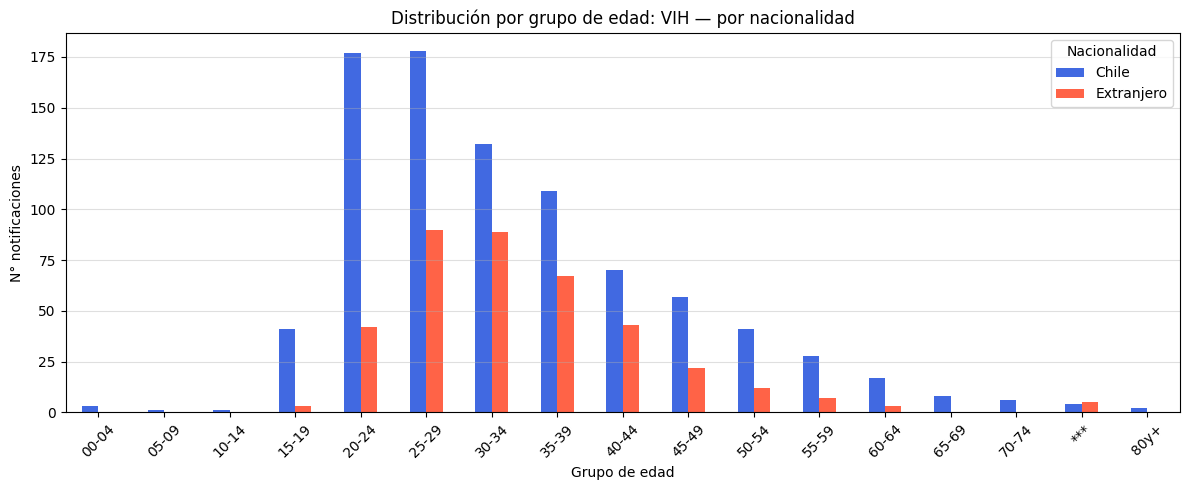

Comentario: se analiza si la distribución etaria difiere entre chilenos y extranjeros para esta enfermedad.


In [10]:
top1_disease = eno_com['ENO'].value_counts().index[0]
print(f'Enfermedad más frecuente: {top1_disease}')

eno_top1 = eno_nat[eno_nat['ENO'] == top1_disease]

age_nat = (eno_top1
           .groupby(['grupo_edad', 'nacionalidad'])
           .size()
           .unstack(fill_value=0))

# Ordenar grupos de edad numéricamente
def age_sort_key(s):
    try:
        return int(str(s).split('-')[0].strip())
    except:
        return 9999

age_nat = age_nat.loc[sorted(age_nat.index, key=age_sort_key)]

fig, ax = plt.subplots(figsize=(12, 5))
age_nat.plot(kind='bar', ax=ax, color=['royalblue', 'tomato'])
ax.set_title(f'Distribución por grupo de edad: {top1_disease} — por nacionalidad')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('N° notificaciones')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Nacionalidad')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print('Comentario: se analiza si la distribución etaria difiere entre chilenos y extranjeros '
      'para esta enfermedad.')

---
## A.3 Vista Espacial (0.5 pts)

### A.3.1 Notificaciones por comuna

> **Caveat:** Los conteos son subestimaciones porque aproximadamente el 45% de las filas ENO tienen `codigo_comuna_residencia == "*****"` (anonimizadas). No se imputan estos registros.


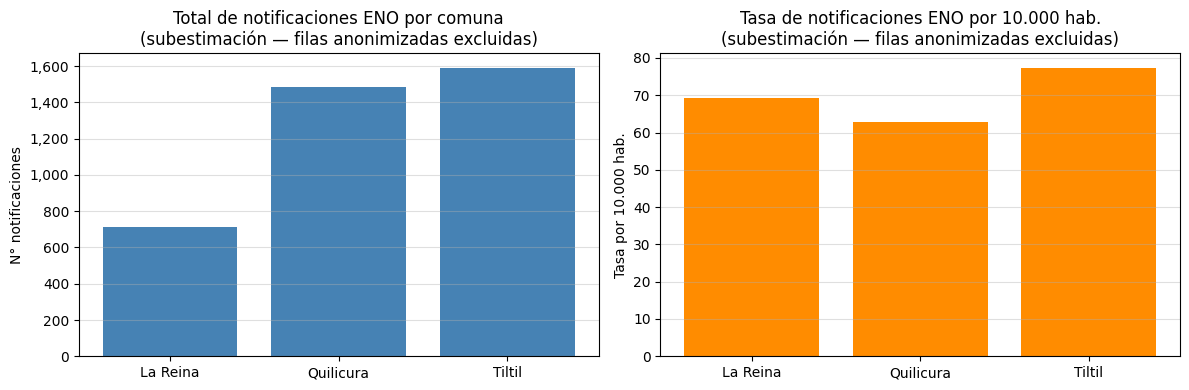

,nombre_comuna,eno_total,pop_total,eno_rate_per_10k
0,La Reina,714,103157,69.2
1,Quilicura,1487,236478,62.9
2,Tiltil,1592,205624,77.4


In [11]:
# Conteos por comuna
counts_com = eno_com.groupby('codigo_comuna_residencia').size().reset_index(name='eno_total')
counts_com['codigo_comuna'] = counts_com['codigo_comuna_residencia'].astype(int)
counts_com['nombre_comuna'] = counts_com['codigo_comuna'].map(COMUNA_NAMES)
counts_com = counts_com.merge(pop_df[['pop_total']].reset_index(), on='codigo_comuna')
counts_com['eno_rate_per_10k'] = counts_com['eno_total'] / counts_com['pop_total'] * 10_000

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(counts_com['nombre_comuna'], counts_com['eno_total'], color='steelblue')
axes[0].set_title('Total de notificaciones ENO por comuna\n(subestimación — filas anonimizadas excluidas)')
axes[0].set_ylabel('N° notificaciones')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(axis='y', alpha=0.4)

axes[1].bar(counts_com['nombre_comuna'], counts_com['eno_rate_per_10k'], color='darkorange')
axes[1].set_title('Tasa de notificaciones ENO por 10.000 hab.\n(subestimación — filas anonimizadas excluidas)')
axes[1].set_ylabel('Tasa por 10.000 hab.')
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

display(counts_com[['nombre_comuna', 'eno_total', 'pop_total', 'eno_rate_per_10k']].round(1))

---
## A.4 Tabla Resumen ENO a Nivel de Comuna (1 pt)


In [12]:
def build_eno_summary(code, grp):
    top3 = ', '.join(grp['ENO'].value_counts().head(3).index.tolist())
    pop  = pop_df.loc[code, 'pop_total'] if code in pop_df.index else np.nan
    return pd.Series({
        'codigo_comuna':     code,
        'nombre_comuna':     COMUNA_NAMES.get(code, ''),
        'eno_total':         len(grp),
        'eno_chilean':       (grp['nacionalidad'] == 'Chile').sum(),
        'eno_foreign':       (grp['nacionalidad'] == 'Extranjero').sum(),
        'eno_desconocido':   (grp['nacionalidad'] == 'Desconocido').sum(),
        'eno_top3_diseases': top3,
        'eno_rate_per_10k':  round(len(grp) / pop * 10_000, 2) if not np.isnan(pop) else np.nan,
    })

rows = []
for code_str, grp in eno_com.groupby('codigo_comuna_residencia'):
    rows.append(build_eno_summary(int(code_str), grp))

eno_summary = pd.DataFrame(rows).reset_index(drop=True)

display(eno_summary)
eno_summary.to_csv('output/tarea2_eno_summary.csv', index=False)
print('✓ Guardado: output/tarea2_eno_summary.csv')

,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
0,13109,La Reina,714,333,149,232,"VIH, Parotiditis, Coqueluche",69.21
1,13122,Quilicura,1487,701,124,662,"VIH, Parotiditis, Coqueluche",62.88
2,13125,Tiltil,1592,769,270,553,"VIH, Parotiditis, Coqueluche",77.42


✓ Guardado: output/tarea2_eno_summary.csv


---
# Parte B: GRD — Egresos Hospitalarios (5 pts)


## B.0 Carga y Limpieza de Datos (1.5 pts)

### B.0.1 Cargar archivos GRD 2022–2024

Los archivos están dentro de ZIP. El encoding varía por año: 2022 y 2023 usan **UTF-16 con BOM**, 2024 usa **Latin-1** sin BOM. El nombre del archivo 2022 dentro del ZIP es `GRD_PUBLICO_EXTERNO_2022.txt`.


In [13]:
grd_cols = ['COMUNA', 'NACIONALIDAD', 'SEXO', 'FECHA_NACIMIENTO',
            'FECHA_INGRESO', 'FECHAALTA', 'TIPOALTA',
            'DIAGNOSTICO1', 'DIAGNOSTICO2',
            'IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD',
            'IR_29301_COD_GRD', 'TIPO_INGRESO', 'ESPECIALIDAD_MEDICA']

frames = []
for year, (zippath, txtname, enc) in GRD_ZIPS.items():
    print(f'  Cargando GRD {year} ({enc})...')
    with zipfile.ZipFile(zippath) as z:
        with z.open(txtname) as f:
            raw = f.read()
    # Detectar BOM para utf-16; para latin-1 no hay BOM
    if raw[:2] in (b'\xff\xfe', b'\xfe\xff'):
        actual_enc = 'utf-16'
    else:
        actual_enc = enc  # latin-1
    
    # Filtrar columnas disponibles (2024 reemplaza CIP_ENCRIPTADO por ID_BENEFICIARIO)
    df_year = pd.read_csv(io.BytesIO(raw), sep='|', encoding=actual_enc,
                          usecols=lambda c: c in grd_cols, low_memory=False)
    df_year['year'] = year
    frames.append(df_year)
    print(f'    → {len(df_year):,} filas')

grd = pd.concat(frames, ignore_index=True)
print(f'\nTotal egresos (3 años): {len(grd):,}')

  Cargando GRD 2022 (utf-16)...


    → 932,840 filas
  Cargando GRD 2023 (utf-16)...


    → 1,039,587 filas
  Cargando GRD 2024 (latin-1)...


    → 1,085,813 filas

Total egresos (3 años): 3,058,240


### B.0.2 Filtrar a las comunas asignadas

En GRD la columna `COMUNA` contiene nombres en mayúsculas (ej. `"QUILICURA"`).


In [14]:
my_grd_names = list(COMUNA_GRD.values())  # ['LA REINA', 'QUILICURA', 'TILTIL']
grd_com = grd[grd['COMUNA'].isin(my_grd_names)].copy()
print(f'Egresos en mis comunas: {len(grd_com):,}')

print('\nEgresos por año:')
display(grd_com.groupby('year').size().reset_index(name='n_egresos'))

print('\nEgresos por comuna y año:')
display(grd_com.groupby(['COMUNA', 'year']).size().unstack(fill_value=0))

Egresos en mis comunas: 29,765

Egresos por año:


,year,n_egresos
0,2022,9371
1,2023,10264
2,2024,10130



Egresos por comuna y año:


year,2022,2023,2024
COMUNA,,,
LA REINA,2385,2562,2619
QUILICURA,6271,6897,6791
TILTIL,715,805,720


### B.0.3 Calcular días de estadía (LOS)


In [15]:
grd_com['fecha_ingreso_dt'] = pd.to_datetime(grd_com['FECHA_INGRESO'], errors='coerce')
grd_com['fecha_alta_dt']    = pd.to_datetime(grd_com['FECHAALTA'],    errors='coerce')
grd_com['los'] = (grd_com['fecha_alta_dt'] - grd_com['fecha_ingreso_dt']).dt.days

# Errores: los < 0
neg_los = (grd_com['los'] < 0).sum()
print(f'Filas con LOS < 0 (errores de datos) eliminadas: {neg_los:,}')
grd_com = grd_com[grd_com['los'] >= 0].copy()

print('\nDistribución de LOS (días de estadía):')
display(grd_com['los'].describe().round(1).to_frame().T)

Filas con LOS < 0 (errores de datos) eliminadas: 0

Distribución de LOS (días de estadía):


,count,mean,std,min,25%,50%,75%,max
los,19501.0,5.8,14.6,0.0,0.0,2.0,6.0,766.0


### B.0.4 Agrupación de nacionalidad


In [16]:
grd_com['nat_group'] = grd_com['NACIONALIDAD'].apply(
    lambda x: 'Chilean' if str(x).strip().upper() == 'CHILE' else 'Foreign')

print('Distribución nat_group:')
ng = grd_com['nat_group'].value_counts()
display(pd.DataFrame({'Conteo': ng, 'Porcentaje (%)': (ng / len(grd_com) * 100).round(1)}))

Distribución nat_group:


,Conteo,Porcentaje (%)
nat_group,,
Chilean,17172,88.1
Foreign,2329,11.9


### B.0.5 Join con CIE-10 para nombres y capítulos diagnósticos


In [17]:
cie10 = pd.read_excel(CIE10_PATH, sheet_name='CIE 10')
# Las columnas reales tienen acentos; las normalizamos para uso consistente
col_map = {
    'Versión':     'Version',
    'Código':      'Codigo',
    'Descripción': 'Descripcion',
    'Categoría':   'Categoria',
    'Sección':     'Seccion',
    'Capítulo':    'Capitulo',
}
cie10 = cie10.rename(columns=col_map)
print('Columnas CIE-10 (normalizadas):', cie10.columns.tolist())
print(f'Filas CIE-10: {len(cie10):,}')

# Normalizar código para hacer match con DIAGNOSTICO1
cie10['Codigo_norm']   = cie10['Codigo'].astype(str).str.strip()
grd_com['DIAG1_norm'] = grd_com['DIAGNOSTICO1'].astype(str).str.strip()

cie10_lookup = cie10[['Codigo_norm', 'Descripcion', 'Capitulo']].drop_duplicates('Codigo_norm')

grd_com = grd_com.merge(cie10_lookup,
                         left_on='DIAG1_norm', right_on='Codigo_norm',
                         how='left')

n_no_match = grd_com['Capitulo'].isna().sum()
pct_no_match = n_no_match / len(grd_com) * 100
print(f'\nFilas sin match en CIE-10: {n_no_match:,} ({pct_no_match:.1f}%)')

Columnas CIE-10 (normalizadas): ['Version', 'Codigo', 'Descripcion', 'Categoria', 'Seccion', 'Capitulo']
Filas CIE-10: 39,873

Filas sin match en CIE-10: 3 (0.0%)


---
## B.1 Perfil Diagnóstico (1.5 pts)

### B.1.1 Top capítulos diagnósticos (CIE-10)


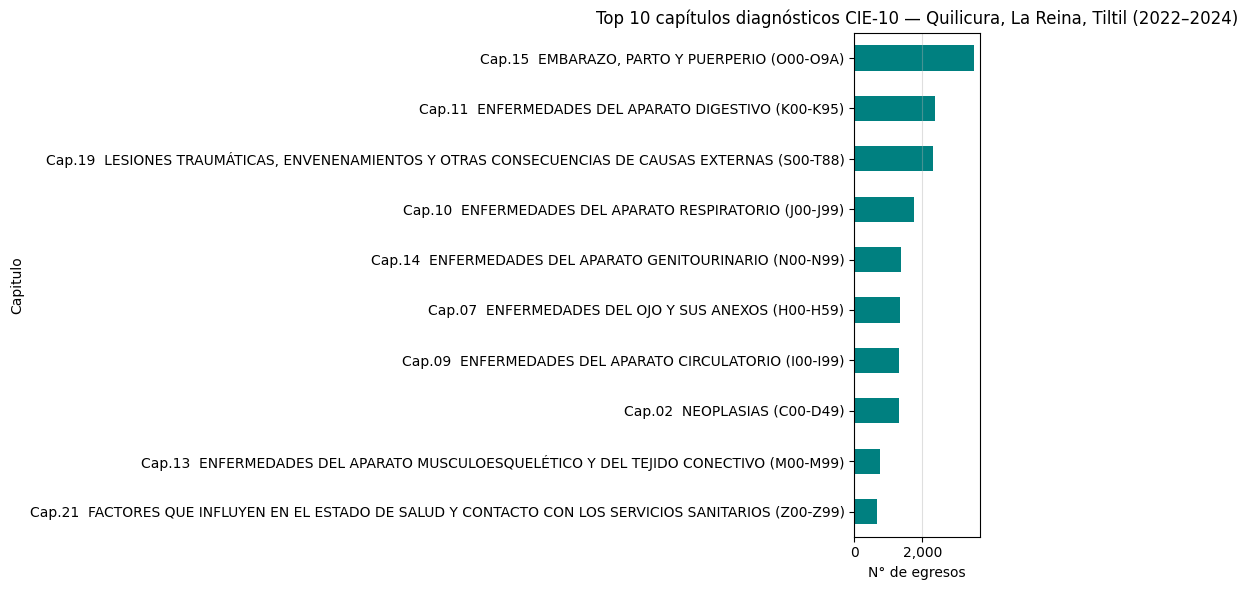


Comentario: los capítulos dominantes revelan las principales causas de hospitalización en las comunas. Típicamente destacan enfermedades del sistema circulatorio, causas externas, tumores y enfermedades del sistema digestivo.


In [18]:
top_chap = grd_com['Capitulo'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
top_chap[::-1].plot(kind='barh', ax=ax, color='teal')
ax.set_title('Top 10 capítulos diagnósticos CIE-10 — Quilicura, La Reina, Tiltil (2022–2024)')
ax.set_xlabel('N° de egresos')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

print('\nComentario: los capítulos dominantes revelan las principales causas de hospitalización '
      'en las comunas. Típicamente destacan enfermedades del sistema circulatorio, '
      'causas externas, tumores y enfermedades del sistema digestivo.')

### B.1.2 Top 15 diagnósticos específicos


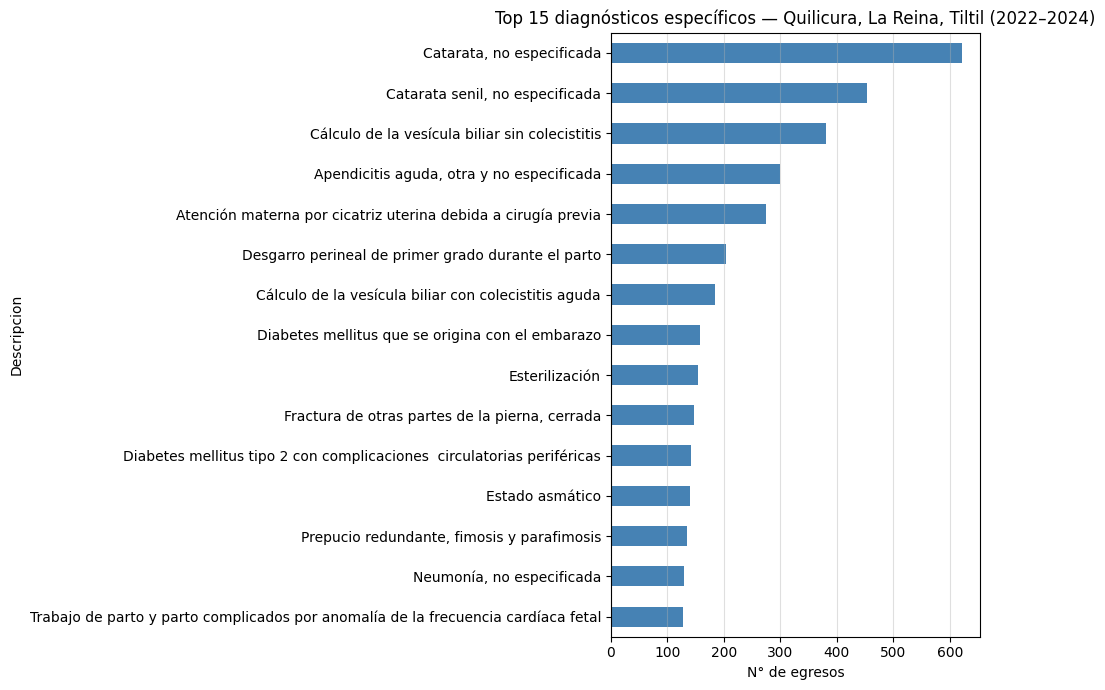

In [19]:
top15_diag = grd_com['Descripcion'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
top15_diag[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 diagnósticos específicos — Quilicura, La Reina, Tiltil (2022–2024)')
ax.set_xlabel('N° de egresos')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

### B.1.3 Capítulos diagnósticos por nacionalidad

Se analiza si los extranjeros están sobrerepresentados en algún capítulo respecto a su participación en la población.


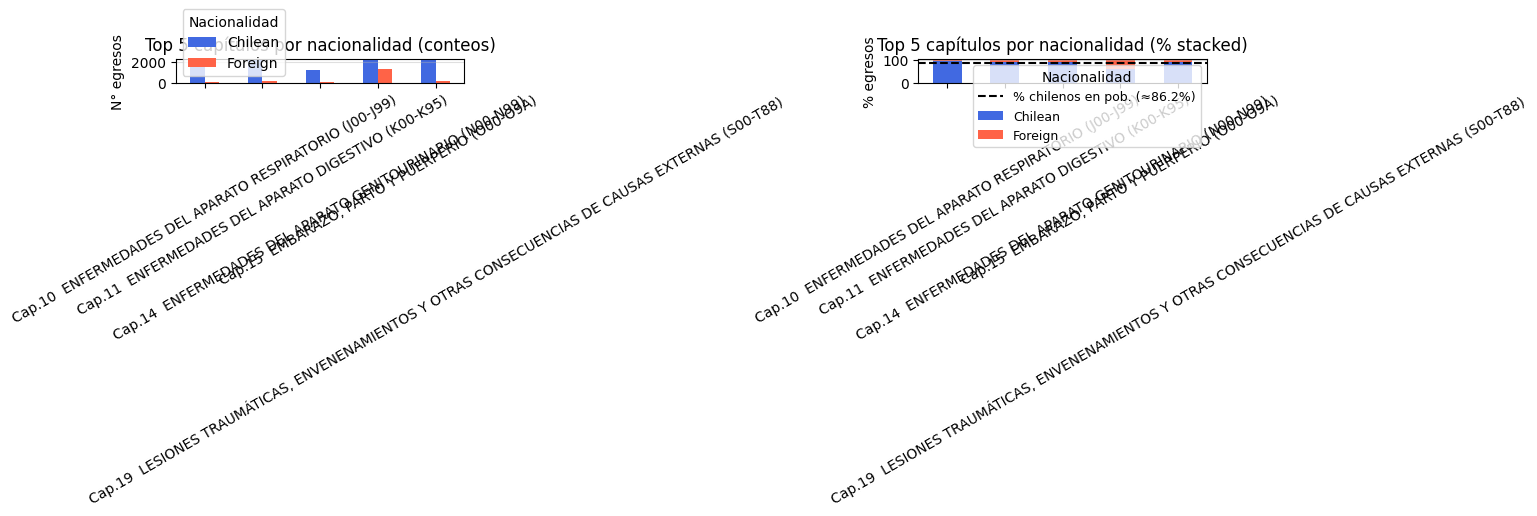

Extranjeros representan en promedio el 13.8% de la población.
Capítulos donde superen este umbral indicarían sobrerepresentación.


nat_group,Chilean,Foreign
Capitulo,,
Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO (J00-J99),96.7,3.3
Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95),91.5,8.5
Cap.14 ENFERMEDADES DEL APARATO GENITOURINARIO (N00-N99),92.2,7.8
"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",61.7,38.3
"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS CONSECUENCIAS DE CAUSAS EXTERNAS (S00-T88)",92.2,7.8


In [20]:
top5_chap = grd_com['Capitulo'].value_counts().head(5).index.tolist()

chap_nat = (grd_com[grd_com['Capitulo'].isin(top5_chap)]
            .groupby(['Capitulo', 'nat_group'])
            .size()
            .unstack(fill_value=0))

chap_nat_pct = chap_nat.div(chap_nat.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

chap_nat.plot(kind='bar', ax=axes[0], color=['royalblue', 'tomato'])
axes[0].set_title('Top 5 capítulos por nacionalidad (conteos)')
axes[0].set_xlabel('')
axes[0].set_ylabel('N° egresos')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Nacionalidad')
axes[0].grid(axis='y', alpha=0.4)

chap_nat_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['royalblue', 'tomato'])
mean_pct_foreign = pop_df['pct_foreign'].mean()
axes[1].axhline(100 - mean_pct_foreign, color='black', linestyle='--',
                label=f'% chilenos en pob. (≈{100-mean_pct_foreign:.1f}%)')
axes[1].set_title('Top 5 capítulos por nacionalidad (% stacked)')
axes[1].set_xlabel('')
axes[1].set_ylabel('% egresos')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Nacionalidad', fontsize=9)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

print(f'Extranjeros representan en promedio el {mean_pct_foreign:.1f}% de la población.')
print('Capítulos donde superen este umbral indicarían sobrerepresentación.')
display(chap_nat_pct.round(1))

---
## B.2 Días de Estadía y Severidad (1 pt)

### B.2.1 Días de estadía por nacionalidad


Días de estadía por nacionalidad:


,media,mediana,min,max
nat_group,,,,
Chilean,6.00,2.0,0.0,766.0
Foreign,4.34,2.0,0.0,169.0


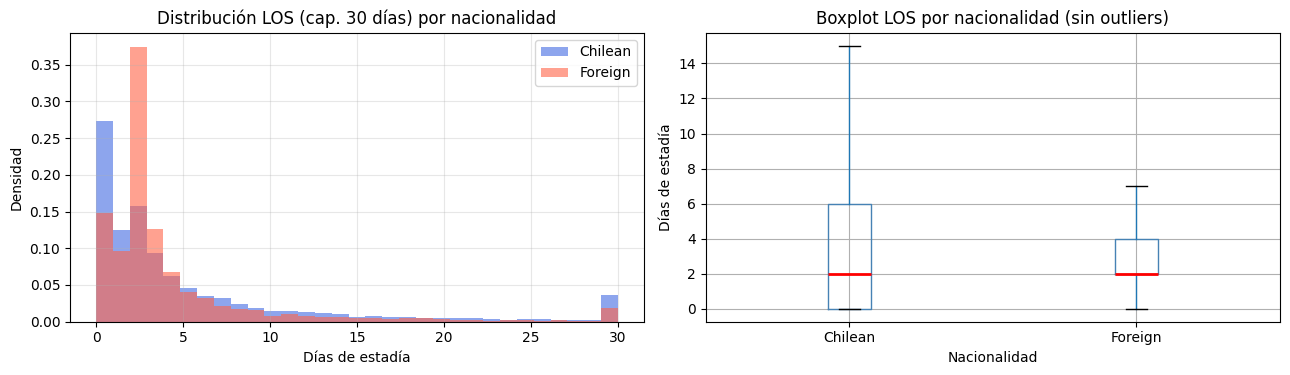

In [21]:
# Tabla resumen
los_summary = (grd_com.groupby('nat_group')['los']
               .agg(media='mean', mediana='median', min='min', max='max')
               .round(2))
print('Días de estadía por nacionalidad:')
display(los_summary)

# Distribución (cap 30 días)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for nat, color in [('Chilean', 'royalblue'), ('Foreign', 'tomato')]:
    subset = grd_com[grd_com['nat_group'] == nat]['los'].clip(upper=30)
    axes[0].hist(subset, bins=31, alpha=0.6, color=color, label=nat, density=True)

axes[0].set_title('Distribución LOS (cap. 30 días) por nacionalidad')
axes[0].set_xlabel('Días de estadía')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(alpha=0.3)

grd_com.boxplot(column='los', by='nat_group', ax=axes[1],
                showfliers=False,
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot LOS por nacionalidad (sin outliers)')
axes[1].set_xlabel('Nacionalidad')
axes[1].set_ylabel('Días de estadía')
plt.suptitle('')
plt.tight_layout()
plt.show()

### B.2.2 Distribución de severidad

`IR_29301_SEVERIDAD`: 0 = Sin severidad, 1 = Menor, 2 = Moderada, 3 = Mayor.


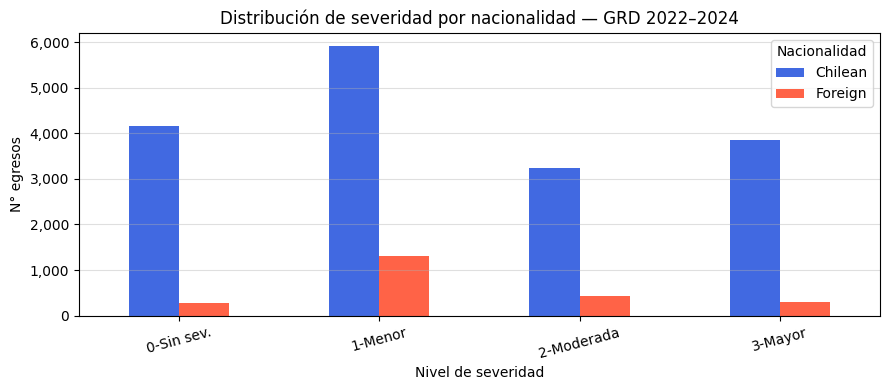

In [22]:
sev_labels = {0: '0-Sin sev.', 1: '1-Menor', 2: '2-Moderada', 3: '3-Mayor'}
grd_com['severidad_label'] = pd.to_numeric(grd_com['IR_29301_SEVERIDAD'], errors='coerce').map(sev_labels)

sev_nat = (grd_com.dropna(subset=['severidad_label'])
           .groupby(['severidad_label', 'nat_group'])
           .size()
           .unstack(fill_value=0))

sev_order = ['0-Sin sev.', '1-Menor', '2-Moderada', '3-Mayor']
sev_nat = sev_nat.reindex([s for s in sev_order if s in sev_nat.index])

fig, ax = plt.subplots(figsize=(9, 4))
sev_nat.plot(kind='bar', ax=ax, color=['royalblue', 'tomato'])
ax.set_title('Distribución de severidad por nacionalidad — GRD 2022–2024')
ax.set_xlabel('Nivel de severidad')
ax.set_ylabel('N° egresos')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Nacionalidad')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### B.2.3 Tipo de alta y mortalidad intrahospitalaria


In [23]:
# Distribución de tipo de alta
print('Distribución de TIPOALTA (total):')
display(grd_com['TIPOALTA'].value_counts().head(10).to_frame())

# Tasa de mortalidad intrahospitalaria por nacionalidad (for-loop para evitar issues de pandas 2.x)
mort_rows = []
for nat, grp in grd_com.groupby('nat_group'):
    mort_rows.append({
        'nat_group':      nat,
        'n_egresos':      len(grp),
        'n_fallecidos':   (grp['TIPOALTA'] == 'FALLECIDO').sum(),
        'mortalidad_pct': round((grp['TIPOALTA'] == 'FALLECIDO').mean() * 100, 2),
    })
mort = pd.DataFrame(mort_rows)

print('\nTasa de mortalidad intrahospitalaria por nacionalidad:')
display(mort)

Distribución de TIPOALTA (total):


,count
TIPOALTA,
DOMICILIO,18264
FALLECIDO,462
DERIVACIÓN OTRO HOSPITAL DEL SERVICIO,197
HOSPITALIZACIÓN DOMICILIARIA,186
ALTA VOLUNTARIA,168
DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL,84
"DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE",57
FUGA DEL PACIENTE,38
DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS,34



Tasa de mortalidad intrahospitalaria por nacionalidad:


,nat_group,n_egresos,n_fallecidos,mortalidad_pct
0,Chilean,17172,433,2.52
1,Foreign,2329,29,1.25


---
## B.3 Vista Espacial: Mapa Coroplético (0.5 pts)

### B.3.1 Tasa de hospitalización por 10.000 hab. por comuna


Tasas de hospitalización:


,nombre_comuna,grd_total,pop_total,hosp_rate_10k
0,La Reina,5004,103157,485.1
1,Quilicura,13062,236478,552.4
2,Tiltil,1435,205624,69.8



Columnas shapefile: ['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna', 'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna', 'Provincia', 'geometry']


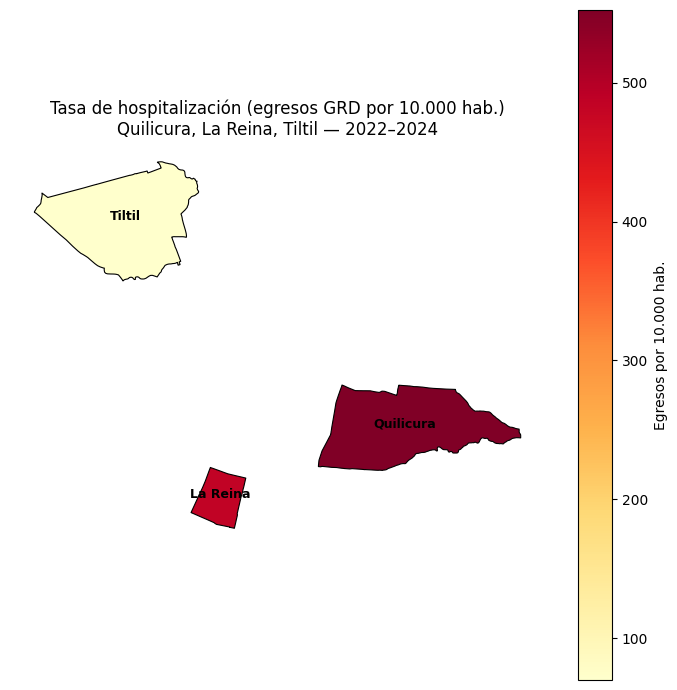

In [24]:
# Calcular tasa de hospitalización por comuna
hosp_rate = (grd_com.groupby('COMUNA').size()
             .reset_index(name='grd_total')
             .assign(codigo_comuna=lambda df: df['COMUNA'].map(GRD_TO_CODE)))
hosp_rate = hosp_rate.merge(pop_df[['pop_total']].reset_index(), on='codigo_comuna')
hosp_rate['hosp_rate_10k'] = hosp_rate['grd_total'] / hosp_rate['pop_total'] * 10_000
hosp_rate['nombre_comuna'] = hosp_rate['codigo_comuna'].map(COMUNA_NAMES)

print('Tasas de hospitalización:')
display(hosp_rate[['nombre_comuna', 'grd_total', 'pop_total', 'hosp_rate_10k']].round(1))

# Mapa coroplético
comunas_gdf = gpd.read_file(SHP_PATH)
print('\nColumnas shapefile:', comunas_gdf.columns.tolist())

# Detectar columna de código comunal
code_col = None
for candidate in ['COD_COMUNA', 'CUT', 'CODIGO', 'cod_comuna', 'cut']:
    if candidate in comunas_gdf.columns:
        code_col = candidate
        break

if code_col:
    comunas_gdf[code_col] = pd.to_numeric(comunas_gdf[code_col], errors='coerce')
    gdf_mis = comunas_gdf[comunas_gdf[code_col].isin(MY_COMUNAS)].copy()
    gdf_mis = gdf_mis.merge(hosp_rate[['codigo_comuna', 'hosp_rate_10k', 'nombre_comuna']],
                             left_on=code_col, right_on='codigo_comuna', how='left')
else:
    # Fallback: buscar por nombre
    name_col = [c for c in comunas_gdf.columns if 'COMU' in c.upper() or 'NOM' in c.upper()]
    print('No se encontró columna de código. Columnas con nombre:', name_col)
    gdf_mis = comunas_gdf[comunas_gdf[name_col[0]].isin(list(COMUNA_GRD.values()))].copy()
    gdf_mis = gdf_mis.merge(hosp_rate[['COMUNA', 'hosp_rate_10k']],
                             left_on=name_col[0], right_on='COMUNA', how='left')

fig, ax = plt.subplots(figsize=(7, 7))
gdf_mis.plot(column='hosp_rate_10k', ax=ax, legend=True,
             legend_kwds={'label': 'Egresos por 10.000 hab.', 'orientation': 'vertical'},
             cmap='YlOrRd', edgecolor='black', linewidth=0.8)

# Etiquetas de comunas
for _, row in gdf_mis.iterrows():
    centroid = row.geometry.centroid
    label = row.get('nombre_comuna', row.get(code_col, ''))
    ax.annotate(str(label), xy=(centroid.x, centroid.y),
                ha='center', fontsize=9, fontweight='bold')

ax.set_title('Tasa de hospitalización (egresos GRD por 10.000 hab.)\nQuilicura, La Reina, Tiltil — 2022–2024',
             fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

---
## B.4 Tabla Resumen GRD a Nivel de Comuna (0.5 pts)


In [25]:
def build_grd_summary(grd_name, grp):
    code = GRD_TO_CODE.get(grd_name, np.nan)
    pop  = pop_df.loc[code, 'pop_total'] if (not np.isnan(code) and code in pop_df.index) else np.nan

    chilean  = grp[grp['nat_group'] == 'Chilean']
    foreign  = grp[grp['nat_group'] == 'Foreign']
    top3_chap = ', '.join(grp['Capitulo'].value_counts().head(3).index.dropna().tolist())
    sev_num  = pd.to_numeric(grp['IR_29301_SEVERIDAD'], errors='coerce')

    return pd.Series({
        'codigo_comuna':        int(code) if not np.isnan(code) else np.nan,
        'nombre_comuna':        COMUNA_NAMES.get(int(code), '') if not np.isnan(code) else '',
        'grd_total':            len(grp),
        'grd_chilean':          len(chilean),
        'grd_foreign':          len(foreign),
        'grd_pct_foreign':      round(len(foreign) / len(grp) * 100, 2),
        'grd_mean_los':         round(grp['los'].mean(), 2),
        'grd_mean_los_chilean': round(chilean['los'].mean(), 2) if len(chilean) else np.nan,
        'grd_mean_los_foreign': round(foreign['los'].mean(), 2) if len(foreign) else np.nan,
        'grd_mean_severity':    round(sev_num.mean(), 3),
        'grd_mortality_rate':   round((grp['TIPOALTA'] == 'FALLECIDO').mean() * 100, 3),
        'grd_top3_chapters':    top3_chap,
        'grd_rate_per_10k':     round(len(grp) / pop * 10_000, 2) if not np.isnan(pop) else np.nan,
    })

rows = []
for grd_name, grp in grd_com.groupby('COMUNA'):
    rows.append(build_grd_summary(grd_name, grp))

grd_summary = pd.DataFrame(rows).reset_index(drop=True)

display(grd_summary)
grd_summary.to_csv('output/tarea2_grd_summary.csv', index=False)
print('✓ Guardado: output/tarea2_grd_summary.csv')

,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13109,La Reina,5004,4692,312,6.24,5.38,5.48,3.85,1.382,2.618,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,485.09
1,13122,Quilicura,13062,11120,1942,14.87,5.90,6.17,4.40,1.393,2.167,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",552.36
2,13125,Tiltil,1435,1360,75,5.23,6.31,6.40,4.75,1.348,3.345,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",69.79


✓ Guardado: output/tarea2_grd_summary.csv
